### PCA Plots
Compares and plots the vectors at each cycle of backpropagation, constructed with vectors from the finalized embeddings.

**Requires** indiv_word_representations.ipynb to be run with the same words as plot words

In [13]:
#indiv_word_representations.ipynb
import os
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import json


def pca_plot(data, fpath, comparing, window):
    points = []
    for word in comparing:
        points.extend([word, np.array(row)] for row in data[word])
    random.shuffle(points)

    labels = np.array([point[0] for point in points])
    lookup, clabels = np.unique(labels, return_inverse=True)
    vectors = np.array([point[1] for point in points])

    pca = PCA(n_components=2)
    features_pca = pca.fit_transform(vectors)

    cmap = plt.cm.get_cmap('tab10', len(comparing))

    fig, ax = plt.subplots(figsize=(5,5))

    ax.scatter(features_pca[:,0], features_pca[:,1], c=clabels, cmap='tab10', s=5, marker='.')

    ax.set_xlabel('PC 1 (%.2f%%)' % (pca.explained_variance_ratio_[0]*100))
    ax.set_ylabel('PC 2 (%.2f%%)' % (pca.explained_variance_ratio_[1]*100))

    ax.legend([mpatches.Patch(color=cmap(b)) for b in range(len(comparing))], lookup)

    title = f"PCA of Words: {', '.join(comparing)}"
    subtitle = f"Window = {window}"

    ax.set_title(f"{title}\n{subtitle}", fontsize=12)

    plt.savefig(fpath, dpi=300)
    plt.show()

In [14]:
# load data generated form indiv_word_representations.ipynb
with open('data/indiv_word_representations/generate_vector_from_bloom.json', 'r') as f:
    vectors_from_bloom = json.load(f)
with open('data/indiv_word_representations/generate_vector_from_iterative_vectors.json', 'r') as f:
    vectors_from_iterative_vectors = json.load(f)

/tmp/ipykernel_191183/835994759.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(comparing))


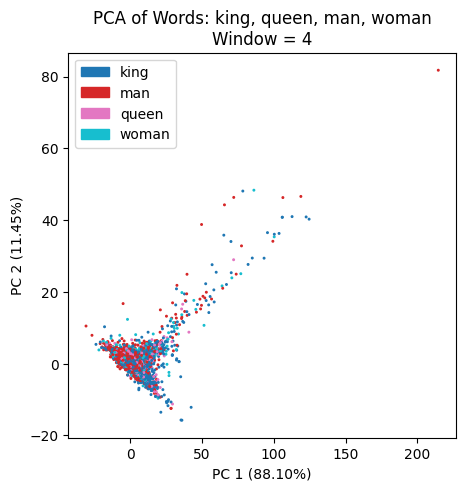

In [15]:
window = 4

set1 = ["king", "queen", "man", "woman"]

prefix1 = ''.join([label[0] for label in set1])

pca_plot(vectors_from_iterative_vectors,f'pca/{prefix1}_iterative_vectors_window_{window}.png',set1,window)

### PCA Plot of vectors over all iterations (final embedding at each iteration level)
1 dot per iteration represetnting the final vector of each iteration

Uses kqmw_embedding.json

/tmp/ipykernel_191183/835994759.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(comparing))


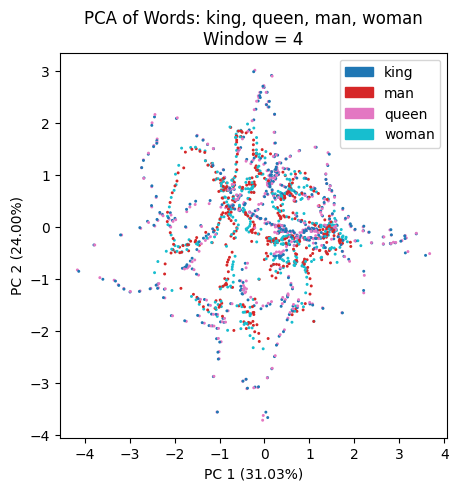

In [ ]:
window = 4

fpath = f'data/kqmw_iteration_window_{window}.json'

with open(fpath, 'r') as f:
    kqmw_iteration = json.load(f)

#sampled_10 = {word:[kqmw_iteration[word][i] for i in range(0,len(kqmw_iteration[word]),10)] for word in kqmw_iteration}
pca_plot(kqmw_iteration,f'pca/kqmw_iteration_snapshots_window_{window}.png',["king", "queen", "man", "woman"],window)